In [1]:
import fastf1
import pandas as pd

# Enable local caching
fastf1.Cache.enable_cache('../data/raw')

# Load a race session
session = fastf1.get_session(2025, 'Bahrain', 'R')

session.load()

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

In [2]:
laps = session.laps

print(laps.head())

                    Time Driver DriverNumber                LapTime  \
0 0 days 00:57:13.827000    PIA           81 0 days 00:01:38.693000   
1 0 days 00:58:51.319000    PIA           81 0 days 00:01:37.492000   
2 0 days 01:00:29.402000    PIA           81 0 days 00:01:38.083000   
3 0 days 01:02:07.535000    PIA           81 0 days 00:01:38.133000   
4 0 days 01:03:45.578000    PIA           81 0 days 00:01:38.043000   

   LapNumber  Stint PitOutTime PitInTime            Sector1Time  \
0        1.0    1.0        NaT       NaT                    NaT   
1        2.0    1.0        NaT       NaT 0 days 00:00:31.139000   
2        3.0    1.0        NaT       NaT 0 days 00:00:31.306000   
3        4.0    1.0        NaT       NaT 0 days 00:00:31.326000   
4        5.0    1.0        NaT       NaT 0 days 00:00:31.305000   

             Sector2Time  ... FreshTyre     Team           LapStartTime  \
0 0 days 00:00:42.130000  ...     False  McLaren 0 days 00:55:34.907000   
1 0 days 00:00:42.34

In [3]:
laps.to_csv('../data/raw/bahrain_2025_laps.csv', index=False)

In [4]:
print(laps.columns.tolist())

['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']


In [5]:
laps.info()

<class 'fastf1.core.Laps'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype          
---  ------              --------------  -----          
 0   Time                1128 non-null   timedelta64[ns]
 1   Driver              1128 non-null   object         
 2   DriverNumber        1128 non-null   object         
 3   LapTime             1115 non-null   timedelta64[ns]
 4   LapNumber           1128 non-null   float64        
 5   Stint               1128 non-null   float64        
 6   PitOutTime          42 non-null     timedelta64[ns]
 7   PitInTime           43 non-null     timedelta64[ns]
 8   Sector1Time         1088 non-null   timedelta64[ns]
 9   Sector2Time         1108 non-null   timedelta64[ns]
 10  Sector3Time         1108 non-null   timedelta64[ns]
 11  Sector1SessionTime  1084 non-null   timedelta64[ns]
 12  Sector2SessionTime  1108 non-null   timedelta64[ns]
 13  Sector3SessionTime  1108 non-null   timedelt

In [6]:
clean_laps = laps.copy()

# Keep only accurate laps
clean_laps = clean_laps[clean_laps["IsAccurate"]]

# Remove laps without valid lap times
clean_laps = clean_laps.dropna(subset=["LapTime"])

# Remove deleted laps
clean_laps = clean_laps[~clean_laps["Deleted"]]

print(clean_laps.info())

<class 'fastf1.core.Laps'>
Index: 924 entries, 1 to 1127
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype          
---  ------              --------------  -----          
 0   Time                924 non-null    timedelta64[ns]
 1   Driver              924 non-null    object         
 2   DriverNumber        924 non-null    object         
 3   LapTime             924 non-null    timedelta64[ns]
 4   LapNumber           924 non-null    float64        
 5   Stint               924 non-null    float64        
 6   PitOutTime          0 non-null      timedelta64[ns]
 7   PitInTime           0 non-null      timedelta64[ns]
 8   Sector1Time         924 non-null    timedelta64[ns]
 9   Sector2Time         924 non-null    timedelta64[ns]
 10  Sector3Time         924 non-null    timedelta64[ns]
 11  Sector1SessionTime  921 non-null    timedelta64[ns]
 12  Sector2SessionTime  924 non-null    timedelta64[ns]
 13  Sector3SessionTime  924 non-null    timedelta64[ns

In [7]:
clean_laps["LapTimeSeconds"] = (
    clean_laps["LapTime"].dt.total_seconds()
)

In [8]:
clean_laps[["Driver", "LapNumber", "LapTimeSeconds"]].head()

,Driver,LapNumber,LapTimeSeconds
1,PIA,2.0,97.492
2,PIA,3.0,98.083
3,PIA,4.0,98.133
4,PIA,5.0,98.043
5,PIA,6.0,98.363


In [9]:
print(clean_laps["Driver"].nunique())
print(clean_laps["Driver"].unique())

20
['PIA' 'RUS' 'NOR' 'LEC' 'HAM' 'VER' 'GAS' 'OCO' 'TSU' 'BEA' 'ANT' 'ALB'
 'HAD' 'DOO' 'ALO' 'LAW' 'STR' 'BOR' 'SAI' 'HUL']


In [10]:
print(clean_laps["Compound"].value_counts())

Compound
MEDIUM    444
HARD      262
SOFT      218
Name: count, dtype: int64


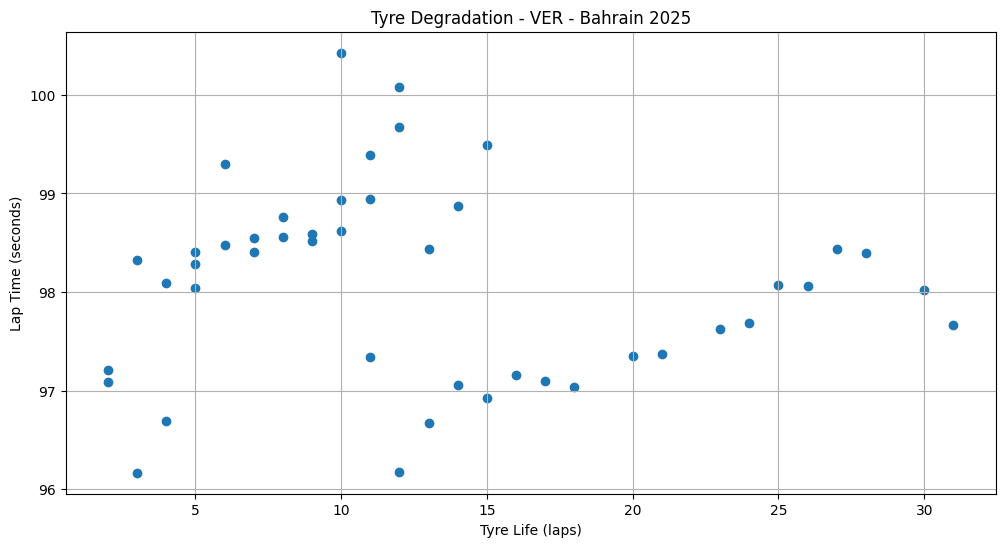

In [11]:
import matplotlib.pyplot as plt

ver_laps = clean_laps[clean_laps["Driver"] == "VER"]

plt.figure(figsize=(12, 6))

plt.scatter(
    ver_laps["TyreLife"],
    ver_laps["LapTimeSeconds"]
)

plt.xlabel("Tyre Life (laps)")
plt.ylabel("Lap Time (seconds)")
plt.title("Tyre Degradation - VER - Bahrain 2025")

plt.grid(True)

plt.show()

In [12]:
clean_laps.to_csv(
    "../data/processed/bahrain_2025_clean.csv",
    index=False
)

In [13]:
clean_laps.info()

<class 'fastf1.core.Laps'>
Index: 924 entries, 1 to 1127
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype          
---  ------              --------------  -----          
 0   Time                924 non-null    timedelta64[ns]
 1   Driver              924 non-null    object         
 2   DriverNumber        924 non-null    object         
 3   LapTime             924 non-null    timedelta64[ns]
 4   LapNumber           924 non-null    float64        
 5   Stint               924 non-null    float64        
 6   PitOutTime          0 non-null      timedelta64[ns]
 7   PitInTime           0 non-null      timedelta64[ns]
 8   Sector1Time         924 non-null    timedelta64[ns]
 9   Sector2Time         924 non-null    timedelta64[ns]
 10  Sector3Time         924 non-null    timedelta64[ns]
 11  Sector1SessionTime  921 non-null    timedelta64[ns]
 12  Sector2SessionTime  924 non-null    timedelta64[ns]
 13  Sector3SessionTime  924 non-null    timedelta64[ns

In [14]:
stint_data = clean_laps.groupby(
    ["Driver", "Stint", "Compound"]
).agg({
    "LapTimeSeconds": ["mean", "min", "max"],
    "TyreLife": "max",
    "LapNumber": "count"
})

stint_data.columns = [
    "AvgLapTime",
    "BestLapTime",
    "WorstLapTime",
    "MaxTyreLife",
    "NumLaps"
]

stint_data = stint_data.reset_index()

stint_data.head()

,Driver,Stint,Compound,AvgLapTime,BestLapTime,WorstLapTime,MaxTyreLife,NumLaps
0,ALB,1.0,SOFT,99.748357,98.699,100.821,15.0,14
1,ALB,2.0,HARD,98.388429,97.209,99.781,15.0,14
2,ALB,3.0,MEDIUM,98.132318,97.141,99.664,25.0,22
3,ALO,1.0,MEDIUM,100.109857,99.318,100.631,15.0,14
4,ALO,2.0,MEDIUM,98.702214,97.955,100.181,15.0,14


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
clean_laps = pd.read_csv(
    "../data/processed/bahrain_2025_clean.csv"
)

In [3]:
clean_laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,LapTimeSeconds
0,0 days 00:58:51.319000,PIA,81,0 days 00:01:37.492000,2.0,1.0,NaN,NaN,0 days 00:00:31.139000,0 days 00:00:42.343000,...,McLaren,0 days 00:57:13.827000,2025-04-13 15:05:28.094,1,1.0,False,NaN,False,True,97.492
1,0 days 01:00:29.402000,PIA,81,0 days 00:01:38.083000,3.0,1.0,NaN,NaN,0 days 00:00:31.306000,0 days 00:00:42.727000,...,McLaren,0 days 00:58:51.319000,2025-04-13 15:07:05.586,1,1.0,False,NaN,False,True,98.083
2,0 days 01:02:07.535000,PIA,81,0 days 00:01:38.133000,4.0,1.0,NaN,NaN,0 days 00:00:31.326000,0 days 00:00:42.796000,...,McLaren,0 days 01:00:29.402000,2025-04-13 15:08:43.669,1,1.0,False,NaN,False,True,98.133
3,0 days 01:03:45.578000,PIA,81,0 days 00:01:38.043000,5.0,1.0,NaN,NaN,0 days 00:00:31.305000,0 days 00:00:42.690000,...,McLaren,0 days 01:02:07.535000,2025-04-13 15:10:21.802,1,1.0,False,NaN,False,True,98.043
4,0 days 01:05:23.941000,PIA,81,0 days 00:01:38.363000,6.0,1.0,NaN,NaN,0 days 00:00:31.336000,0 days 00:00:42.880000,...,McLaren,0 days 01:03:45.578000,2025-04-13 15:11:59.845,1,1.0,False,NaN,False,True,98.363


In [4]:
clean_laps.shape

(924, 32)

In [5]:
stint_data = clean_laps.groupby(
    ["Driver", "Stint", "Compound"]
).agg(
    AvgLapTime=("LapTimeSeconds", "mean"),
    BestLapTime=("LapTimeSeconds", "min"),
    WorstLapTime=("LapTimeSeconds", "max"),
    MaxTyreLife=("TyreLife", "max"),
    NumLaps=("LapNumber", "count")
).reset_index()

stint_data.head()

,Driver,Stint,Compound,AvgLapTime,BestLapTime,WorstLapTime,MaxTyreLife,NumLaps
0,ALB,1.0,SOFT,99.748357,98.699,100.821,15.0,14
1,ALB,2.0,HARD,98.388429,97.209,99.781,15.0,14
2,ALB,3.0,MEDIUM,98.132318,97.141,99.664,25.0,22
3,ALO,1.0,MEDIUM,100.109857,99.318,100.631,15.0,14
4,ALO,2.0,MEDIUM,98.702214,97.955,100.181,15.0,14


In [6]:
stint_data.to_csv(
    "../data/processed/stint_data.csv",
    index=False
)

In [7]:
clean_laps["Compound"].value_counts()

Compound
MEDIUM    444
HARD      262
SOFT      218
Name: count, dtype: int64

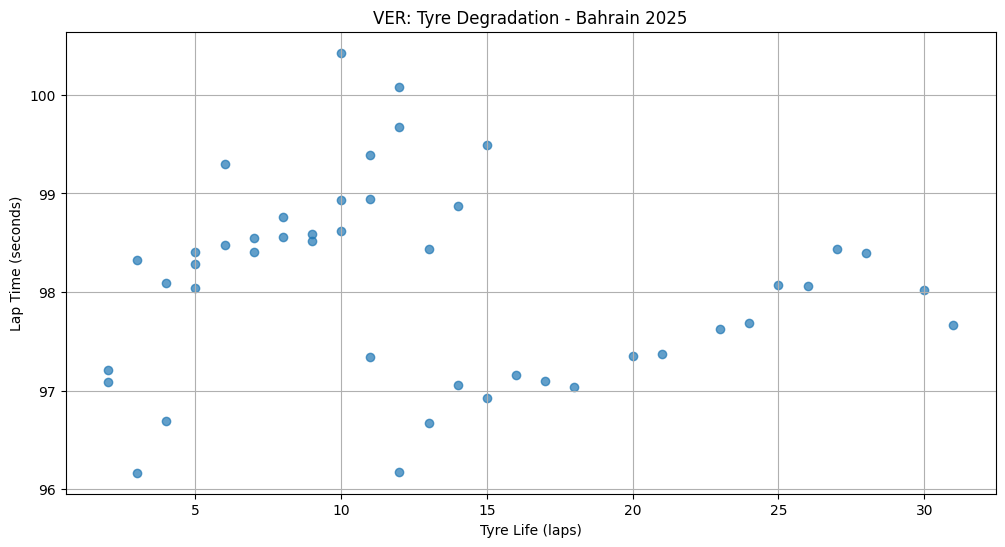

In [8]:
ver_laps = clean_laps[
    clean_laps["Driver"] == "VER"
]

plt.figure(figsize=(12, 6))

plt.scatter(
    ver_laps["TyreLife"],
    ver_laps["LapTimeSeconds"],
    alpha=0.7
)

plt.xlabel("Tyre Life (laps)")
plt.ylabel("Lap Time (seconds)")
plt.title("VER: Tyre Degradation - Bahrain 2025")

plt.grid(True)

plt.show()

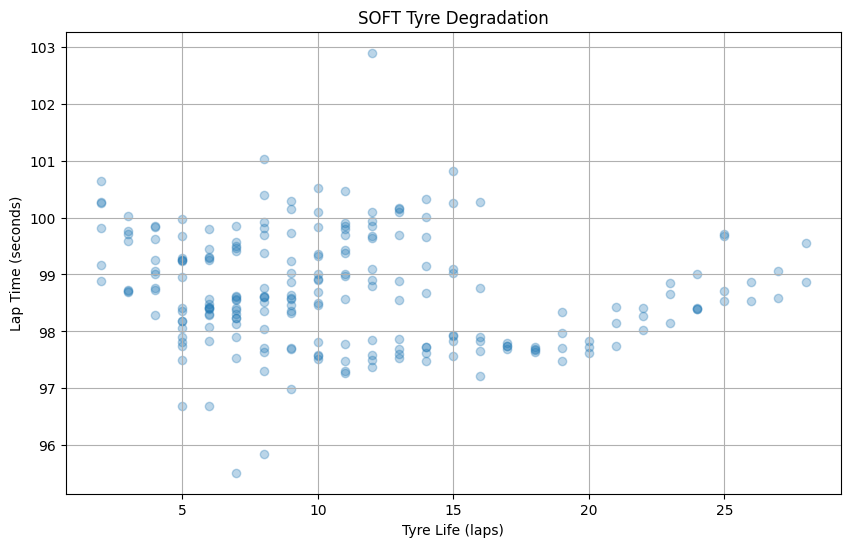

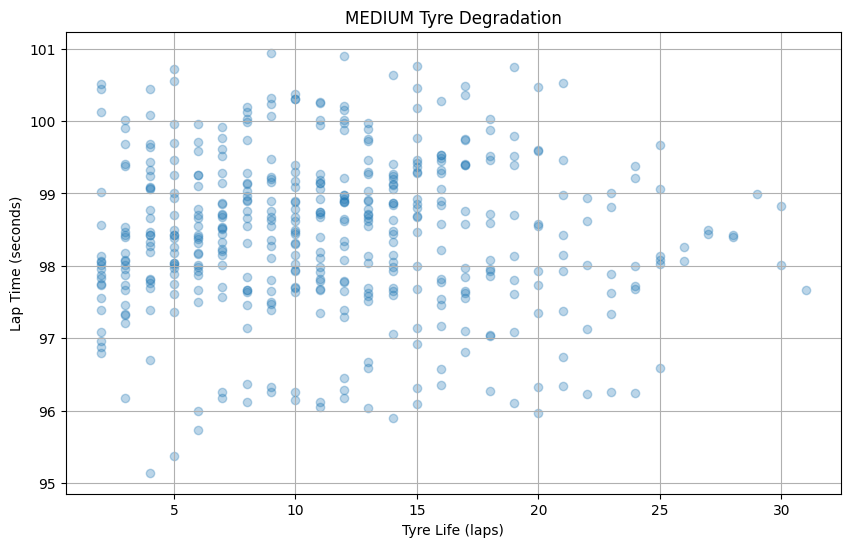

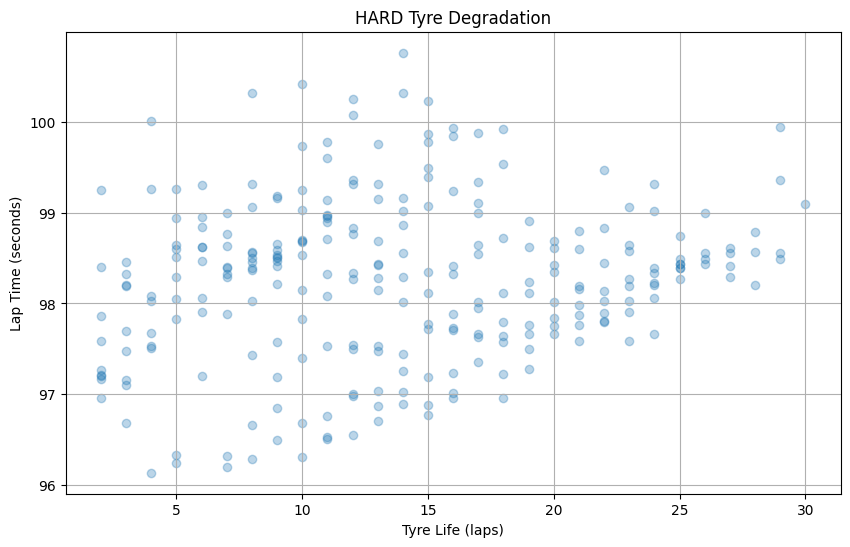

In [9]:
for compound in clean_laps["Compound"].unique():

    compound_data = clean_laps[
        clean_laps["Compound"] == compound
    ]

    plt.figure(figsize=(10, 6))

    plt.scatter(
        compound_data["TyreLife"],
        compound_data["LapTimeSeconds"],
        alpha=0.3
    )

    plt.title(f"{compound} Tyre Degradation")

    plt.xlabel("Tyre Life (laps)")
    plt.ylabel("Lap Time (seconds)")

    plt.grid(True)

    plt.show()

In [10]:
degradation = (
    clean_laps.groupby(
        ["Driver", "Compound"]
    )
    .apply(
        lambda x: x["LapTimeSeconds"].corr(
            x["TyreLife"]
        )
    )
    .reset_index(name="DegradationScore")
)

degradation.sort_values(
    by="DegradationScore",
    ascending=False
).head(10)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13412\3755432678.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,Driver,Compound,DegradationScore
16,GAS,SOFT,0.952863
48,VER,SOFT,0.915850
27,LEC,HARD,0.908230
35,PIA,SOFT,0.906020
30,NOR,SOFT,0.901383
39,SAI,MEDIUM,0.895115
33,OCO,SOFT,0.863431
38,SAI,HARD,0.842317
44,TSU,MEDIUM,0.840528
12,DOO,MEDIUM,0.832894


In [11]:
degradation = (
    clean_laps.groupby(
        ["Driver", "Compound"]
    )
    .apply(
        lambda x: x["LapTimeSeconds"].corr(
            x["TyreLife"]
        )
    )
    .reset_index(name="DegradationScore")
)

degradation.sort_values(
    by="DegradationScore",
    ascending=False
).head(10)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13412\3755432678.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,Driver,Compound,DegradationScore
16,GAS,SOFT,0.952863
48,VER,SOFT,0.915850
27,LEC,HARD,0.908230
35,PIA,SOFT,0.906020
30,NOR,SOFT,0.901383
39,SAI,MEDIUM,0.895115
33,OCO,SOFT,0.863431
38,SAI,HARD,0.842317
44,TSU,MEDIUM,0.840528
12,DOO,MEDIUM,0.832894


In [12]:
degradation.to_csv(
    "../data/processed/degradation_scores.csv",
    index=False
)

In [13]:
clean_laps["PitLap"] = (
    clean_laps["PitInTime"].notna()
).astype(int)

In [14]:
clean_laps["PitLap"].value_counts()

PitLap
0    924
Name: count, dtype: int64

In [16]:
pit_laps = clean_laps[
    clean_laps["PitLap"] == 1
]

pit_laps[
    ["Driver", "LapNumber", "Compound", "TyreLife"]
].head(10)

,Driver,LapNumber,Compound,TyreLife


In [17]:
clean_laps["PitInTime"].head()

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: PitInTime, dtype: float64

In [18]:
clean_laps["PitInTime"].isna().sum()

np.int64(924)

In [19]:
clean_laps["PitInTime"].dtype

dtype('float64')

In [20]:
clean_laps["PitLap"] = (
    clean_laps.groupby("Driver")["Stint"]
    .diff()
    .fillna(0)
    .gt(0)
    .astype(int)
)

In [21]:
clean_laps["PitLap"].value_counts()

PitLap
0    883
1     41
Name: count, dtype: int64

In [22]:
pit_laps = clean_laps[
    clean_laps["PitLap"] == 1
]

pit_laps[
    ["Driver", "LapNumber", "Compound", "TyreLife", "Stint"]
].head(10)

,Driver,LapNumber,Compound,TyreLife,Stint
12,PIA,16.0,MEDIUM,2.0,2.0
27,PIA,36.0,MEDIUM,4.0,3.0
60,RUS,15.0,MEDIUM,2.0,2.0
77,RUS,36.0,SOFT,7.0,3.0
87,NOR,12.0,MEDIUM,2.0,2.0
107,NOR,37.0,MEDIUM,5.0,3.0
142,LEC,19.0,MEDIUM,2.0,2.0
155,LEC,36.0,HARD,4.0,3.0
191,HAM,19.0,MEDIUM,2.0,2.0
204,HAM,36.0,HARD,4.0,3.0


In [23]:
clean_laps = clean_laps.sort_values(
    by=["Driver", "LapNumber"]
).reset_index(drop=True)

In [24]:
total_laps = clean_laps["LapNumber"].max()

clean_laps["LapsRemaining"] = (
    total_laps - clean_laps["LapNumber"]
)

clean_laps["RaceProgress"] = (
    clean_laps["LapNumber"] / total_laps
)

In [25]:
clean_laps["AvgPaceLast5"] = (
    clean_laps.groupby("Driver")["LapTimeSeconds"]
    .transform(
        lambda x: x.rolling(
            window=5,
            min_periods=1
        ).mean()
    )
)

In [26]:
clean_laps["DegradationRate"] = (
    clean_laps["LapTimeSeconds"] -
    clean_laps["AvgPaceLast5"]
)

In [27]:
clean_laps["PositionChange"] = (
    clean_laps.groupby("Driver")["Position"]
    .diff()
    .fillna(0)
)

In [28]:
clean_laps["PitNextLap"] = (
    clean_laps.groupby("Driver")["PitLap"]
    .shift(-1)
    .fillna(0)
    .astype(int)
)

In [29]:
clean_laps["PitNextLap"].value_counts()

PitNextLap
0    883
1     41
Name: count, dtype: int64

In [30]:
features = [
    "LapNumber",
    "TyreLife",
    "Position",
    "LapsRemaining",
    "RaceProgress",
    "AvgPaceLast5",
    "DegradationRate"
]

target = "PitNextLap"

In [31]:
model_data = clean_laps[
    features + [target]
].dropna()

In [32]:
model_data.head()

,LapNumber,TyreLife,Position,LapsRemaining,RaceProgress,AvgPaceLast5,DegradationRate,PitNextLap
0,2.0,2.0,14.0,55.0,0.035088,99.82100,0.00000,0
1,3.0,3.0,13.0,54.0,0.052632,99.26000,-0.56100,0
2,4.0,4.0,13.0,53.0,0.070175,99.19200,-0.13600,0
3,5.0,5.0,13.0,52.0,0.087719,99.20825,0.04875,0
4,6.0,6.0,13.0,51.0,0.105263,99.21920,0.04380,0


In [33]:
model_data.to_csv(
    "../data/processed/model_data.csv",
    index=False
)

In [34]:
model_data.shape

(924, 8)

In [35]:
model_data["PitNextLap"].value_counts()

PitNextLap
0    883
1     41
Name: count, dtype: int64